# Análise Exploratória e Modelagem Preditiva

Problema e Coleta de Dados

O objetivo deste projeto é desenvolver um modelo de Machine Learning capaz de prever a ocorrência de doença cardiovascular com base em características clínicas e demográficas dos pacientes.

O problema é de classificação binária:

- 0 → Sem doença cardiovascular  
- 1 → Com doença cardiovascular  

Este tipo de problema possui grande relevância na área da saúde, pois permite a identificação precoce de pacientes com risco elevado, auxiliando na tomada de decisão médica.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de ML
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Pipeline e pré-processamento
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Split treino/teste
from sklearn.model_selection import train_test_split

# Métricas
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.calibration import calibration_curve

# SHAP (para explicabilidade)
import shap

%matplotlib inline



e:\ONEDRIVE\Documentos\FIAP-POS\PROJETO-AVC\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carregamento e Limpeza dos Dados

Inicialmente, o conjunto de dados foi carregado e passou por um processo de limpeza para garantir maior qualidade das informações.

Foram realizadas as seguintes etapas:

- Remoção da coluna `id`, por não possuir valor preditivo
- Filtragem de valores inconsistentes (outliers extremos)
- Padronização dos dados para análise

A remoção de outliers é essencial para evitar distorções nos modelos e garantir maior robustez nas previsões.

In [ ]:
# =========================
# LOAD + LIMPEZA
# =========================

# Carregar dataset
df = pd.read_csv("../data/cardio_train.csv", sep=";")

# Remover ID (não é necessário para o modelo)
if "id" in df.columns:
    df = df.drop(columns=["id"])

# remover outliers
df = df[(df["ap_hi"] > 80) & (df["ap_hi"] < 250)]
df = df[(df["ap_lo"] > 50) & (df["ap_lo"] < 150)]

## Engenharia de Atributos (Feature Engineering)

Foram criadas novas variáveis com o objetivo de melhorar a capacidade preditiva do modelo.

Dentre as principais transformações, destacam-se:

- Conversão da idade de dias para anos (`age_years`)
- Cálculo do índice de massa corporal (`bmi`)
- Criação de métricas de pressão arterial:
  - `pulse_pressure` (diferença entre pressão sistólica e diastólica)
  - `mean_pressure` (média das pressões)
- Criação de variáveis indicadoras de risco:
  - pressão alta
  - colesterol elevado
  - glicose elevada
- Criação de um score de risco (`risk_score`)
- Interação entre idade e pressão (`pressure_age`)

Essas variáveis simulam indicadores clínicos reais e ajudam o modelo a capturar padrões mais complexos.

In [2]:
# =========================
# FEATURE ENGINEERING
# =========================
df["age_years"] = df["age"] / 365

df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
df["mean_pressure"] = (df["ap_hi"] + df["ap_lo"]) / 2

df["high_pressure"] = (df["ap_hi"] > 140).astype(int)
df["high_cholesterol"] = (df["cholesterol"] > 1).astype(int)
df["high_glucose"] = (df["gluc"] > 1).astype(int)

df["risk_score"] = (
    df["high_pressure"] +
    df["high_cholesterol"] +
    df["high_glucose"] +
    df["smoke"]
)

df["pressure_age"] = df["ap_hi"] * df["age_years"]

In [ ]:
# =========================
# SPLIT TREINO/TESTE
# =========================

X = df.drop("cardio", axis=1)
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Análise Exploratória dos Dados (EDA)

### Mapa de Correlação

O mapa de correlação permite identificar relações entre as variáveis do conjunto de dados.

Observa-se que variáveis relacionadas à pressão arterial, idade e BMI apresentam maior correlação com a variável alvo (doença cardiovascular).

Essa análise é importante para entender quais atributos possuem maior potencial preditivo.

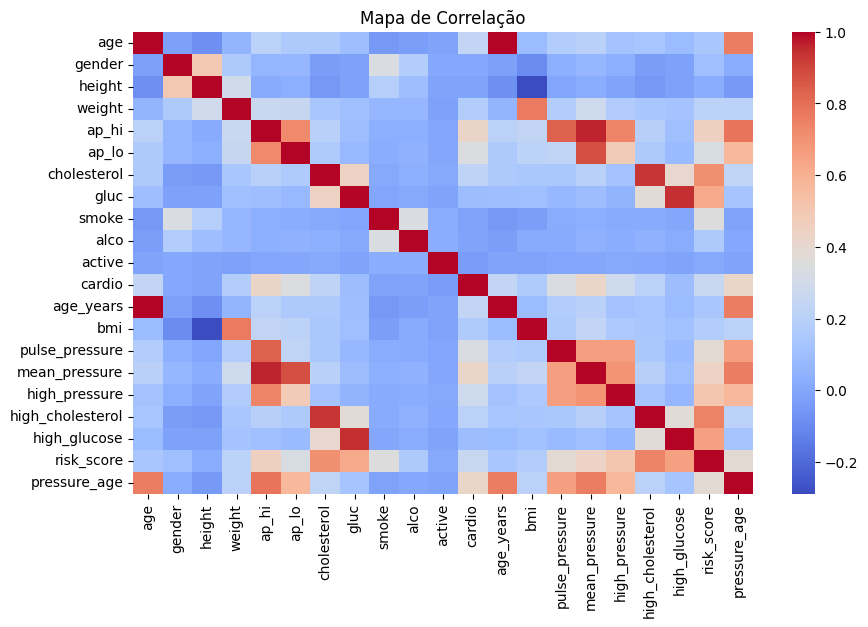

In [4]:
# =========================
# EDA
# =========================

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Mapa de Correlação")
plt.show()

### Distribuição das Variáveis

Foram utilizados boxplots para analisar a distribuição de variáveis importantes em relação à presença de doença cardiovascular.

Nos gráficos, é possível observar:

- A **linha central** representa a mediana
- A **caixa** representa a faixa entre o primeiro e terceiro quartil (50% dos dados)
- As **linhas verticais** representam a dispersão dos dados
- Os **pontos fora da caixa (outliers)** representam valores extremos

### Principais insights:

- Pacientes com doença cardiovascular tendem a apresentar:
  - maior idade
  - maior pressão arterial
  - maior BMI

Essas diferenças indicam que as variáveis possuem capacidade de discriminar entre as classes.

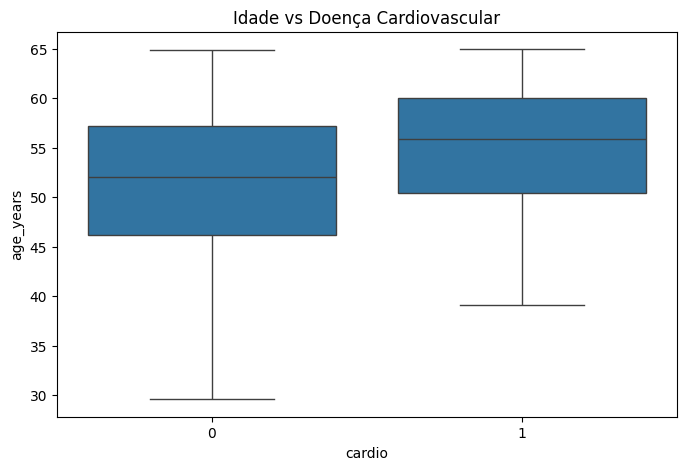

In [5]:
# Boxplots
plt.figure(figsize=(8,5))
sns.boxplot(x="cardio", y="age_years", data=df)
plt.title("Idade vs Doença Cardiovascular")
plt.show()

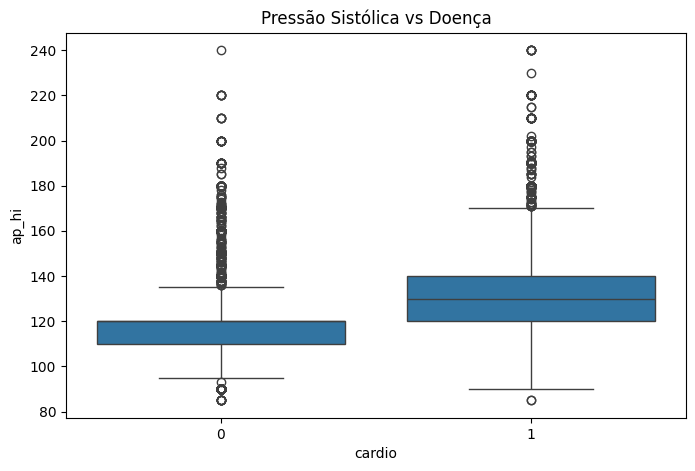

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cardio", y="ap_hi", data=df)
plt.title("Pressão Sistólica vs Doença")
plt.show()

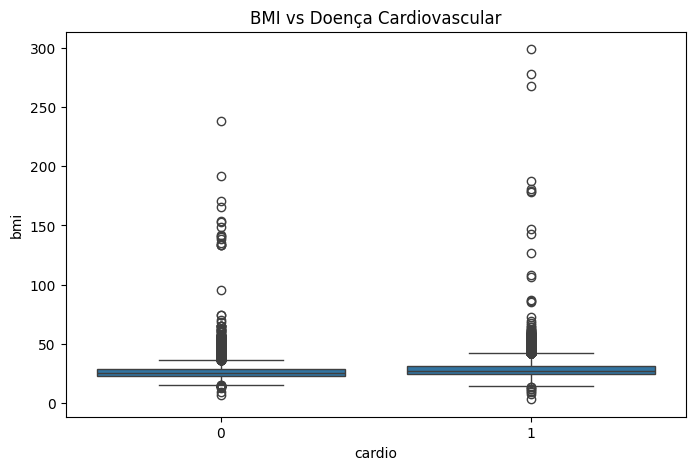

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cardio", y="bmi", data=df)
plt.title("BMI vs Doença Cardiovascular")
plt.show()

## Treinamento e Comparação de Modelos

Foram avaliados diferentes algoritmos de Machine Learning:

- Regressão Logística
- Random Forest
- XGBoost

A comparação foi realizada com base nas seguintes métricas:

- Accuracy (Acurácia)
- Precision (Precisão)
- Recall (Sensibilidade)
- F1-score

Embora a acurácia seja uma métrica importante, o foco principal foi o **Recall**, devido à natureza do problema.

In [8]:
# =========================
# MODELOS (COMPARAÇÃO)
# =========================

models = {
    "XGBoost": XGBClassifier(eval_metric="logloss"),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    results.append({
        "Modelo": name,
        "Accuracy": acc,
        "Recall": recall,
        "Precision": precision,
        "F1-score": f1
    })

## Resultados da Comparação

Os modelos apresentaram desempenhos próximos em termos de acurácia, porém diferenças importantes em relação ao recall.

Em problemas médicos, é fundamental minimizar falsos negativos, ou seja, evitar classificar pacientes doentes como saudáveis.

Por esse motivo, o modelo escolhido foi aquele com melhor equilíbrio entre recall e precisão.

In [9]:
# =========================
# RESULTADOS (TABELA)
# =========================

results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)
results_df

,Modelo,Accuracy,Recall,Precision,F1-score
2,Random Forest,0.711879,0.692092,0.716463,0.704067
1,Logistic Regression,0.728725,0.691651,0.742844,0.716334
0,XGBoost,0.725735,0.684583,0.741704,0.711999


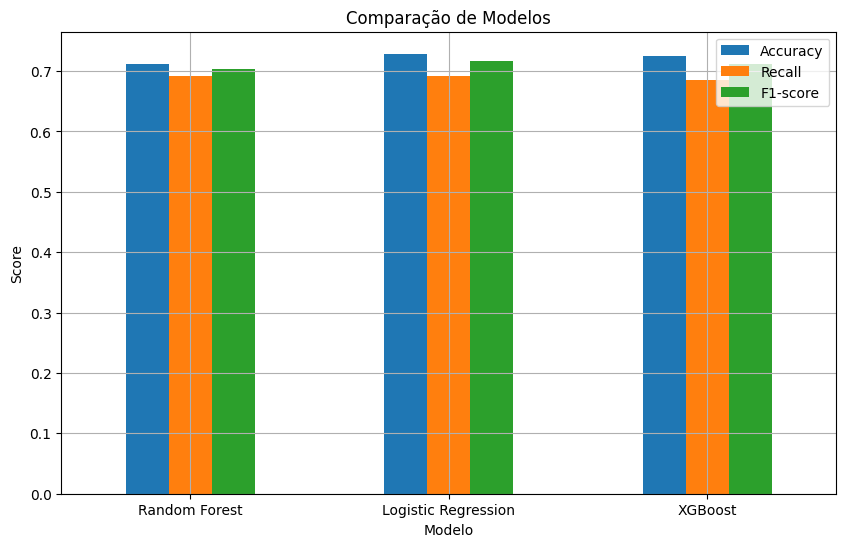

In [10]:
results_df.set_index("Modelo")[["Accuracy", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparação de Modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()
plt.show()

In [11]:
best_model_name = results_df.iloc[0]["Modelo"]
best_model = models[best_model_name]

print(f"Melhor modelo: {best_model_name}")

Melhor modelo: Random Forest


## Seleção do Modelo Final

Para treinando do modelo (train_model) XGBoost foi selecionado como modelo final devido à sua capacidade de:

- Capturar relações não lineares
- Lidar com interações entre variáveis
- Apresentar melhor desempenho geral

Além disso, foi possível realizar ajuste de hiperparâmetros (tuning), melhorando ainda mais sua performance.

## Ajuste do Threshold (Limiar de Decisão)

Por padrão, modelos de classificação utilizam 0.5 como limite para decisão.

Neste trabalho, foi realizado um ajuste do threshold com o objetivo de priorizar a detecção de pacientes doentes.

O modelo (train_model) foi configurado para atingir um **recall mínimo de 80%**, reduzindo a quantidade de falsos negativos.

Essa abordagem é fundamental em contextos médicos, onde a falha em identificar um paciente doente pode ter consequências graves.

## Curva ROC

A curva ROC avalia a capacidade do modelo de separar as classes.

Quanto mais próxima a curva estiver do canto superior esquerdo, melhor o desempenho do modelo.

O valor de AUC (Área sob a curva) resume essa capacidade:
- Quanto mais próximo de 1, melhor

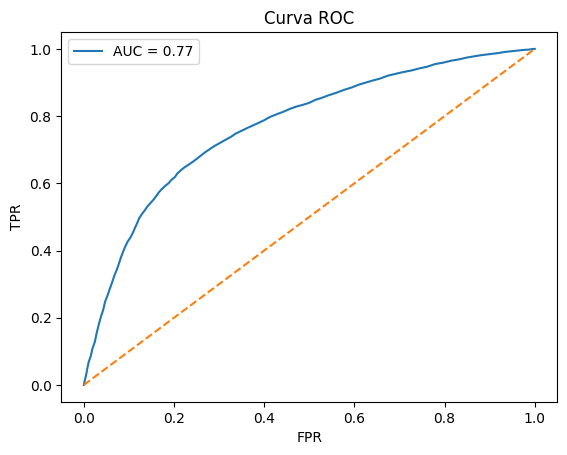

In [12]:
# =========================
# CURVA ROC
# =========================
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC")
plt.legend()
plt.show()

## Curva Precision-Recall

A curva Precision-Recall é mais adequada para cenários com possível desbalanceamento de classes.

Ela mostra o trade-off entre:
- Precisão (quantos positivos estão corretos)
- Recall (quantos positivos foram detectados)

Essa análise reforça a escolha do modelo com foco em recall.

## Calibration Curve

A curva de calibração avalia se as probabilidades previstas pelo modelo correspondem à realidade.

Um modelo bem calibrado apresenta valores próximos da linha diagonal.

Isso é importante em aplicações onde a probabilidade em si é relevante, como análise de risco.

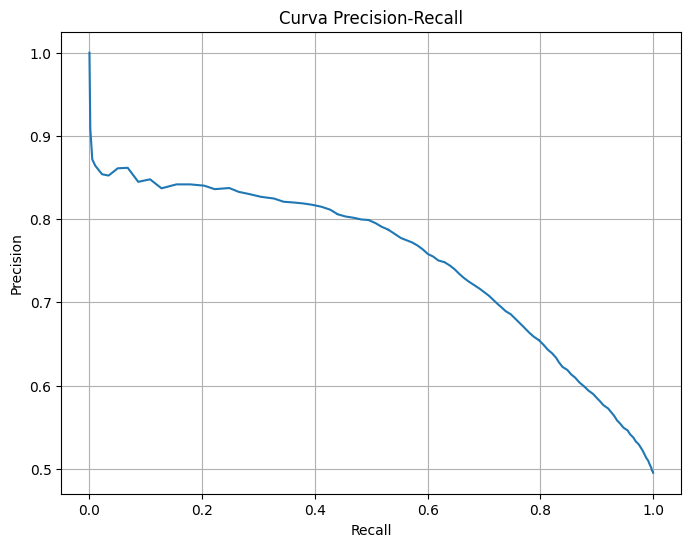

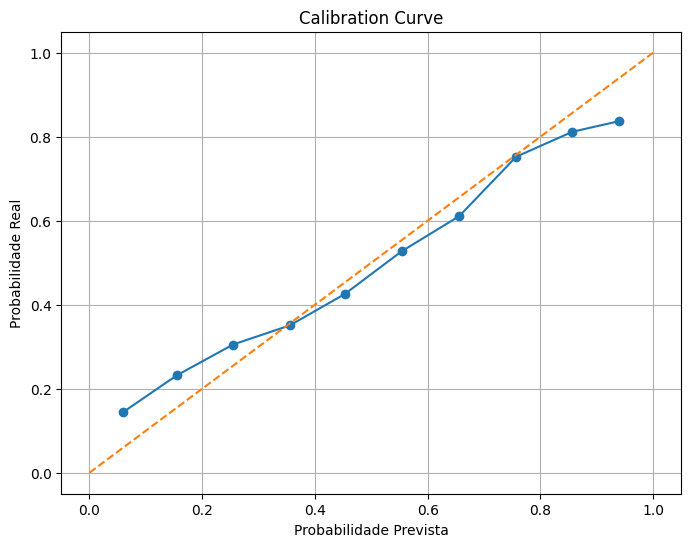

In [13]:
# =========================
# PRECISION-RECALL
# =========================

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.grid()
plt.show()


# =========================
# CALIBRATION CURVE
# =========================
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Probabilidade Prevista")
plt.ylabel("Probabilidade Real")
plt.title("Calibration Curve")
plt.grid()
plt.show()

## Importância das Variáveis

A análise de importância das variáveis permite identificar quais atributos mais influenciam o modelo.

Observa-se que variáveis relacionadas à pressão arterial, idade e BMI possuem maior impacto na previsão.

Isso está alinhado com o conhecimento médico sobre fatores de risco cardiovascular.

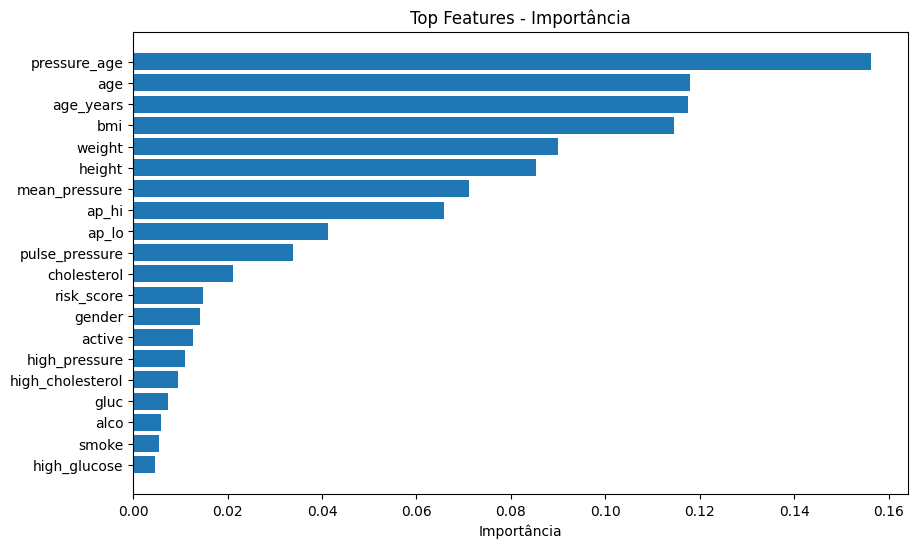

In [14]:
# =========================
# FEATURE IMPORTANCE
# =========================
if hasattr(best_model, "feature_importances_"):
    importance = best_model.feature_importances_
else:
    importance = abs(best_model.coef_[0])

feat_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_importance["feature"], feat_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Top Features - Importância")
plt.xlabel("Importância")
plt.show()

## Interpretabilidade do Modelo (SHAP)

O SHAP (SHapley Additive exPlanations) foi utilizado para interpretar as decisões do modelo.

Ele permite entender:
- Quais variáveis influenciam cada previsão
- Como cada variável contribui positiva ou negativamente

Essa análise aumenta a transparência do modelo, o que é essencial em aplicações na área da saúde.

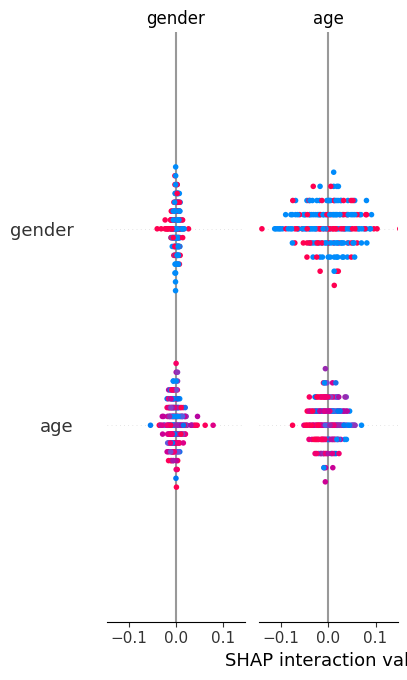

In [15]:
# =========================
# SHAP (INTERPRETAÇÃO)
# =========================
# SHAP só para modelos de árvore
if best_model_name in ["XGBoost", "Random Forest"]:
    
    explainer = shap.TreeExplainer(best_model)

    X_test_sample = X_test.sample(200, random_state=42)
    shap_values_sample = explainer.shap_values(X_test_sample)

    shap.summary_plot(shap_values_sample, X_test_sample)

else:
    print("SHAP não aplicado para Logistic Regression")